In [ ]:
"""
Author    : Mohammad Norizadeh Cherloo
Project   : MNIST Digit Classification
Algorithm : Visual Geometry Group (VGG) – PyTorch
"""
import torch
from sklearn import  metrics
from matplotlib import pyplot as plt
from sklearn import preprocessing as prep
from torch.utils.data import TensorDataset,DataLoader,Dataset
import pandas as pd
from sklearn.model_selection import train_test_split
import numpy as np
from sklearn.datasets import load_digits
from torch.nn import functional as F
import torchvision
from torchvision.transforms import ToTensor, Lambda
from torch import nn, optim

In [9]:
from torch.utils.data import DataLoader, random_split

# %% MNIST dataset
num_classes = 10
batch_size = 32

# target_transform = Lambda(
#     lambda y: torch.zeros(num_classes).scatter_(0, torch.tensor(y), 1)
# )

full_train_dataset = torchvision.datasets.MNIST(
    root='./data',
    train=True,
    transform=ToTensor(),
    download=True
)

test_dataset = torchvision.datasets.MNIST(
    root='./data',
    train=False,
    transform=ToTensor(),
)


In [10]:
train_size = 50000
val_size   = 10000

train_dataset, val_dataset = random_split(
    full_train_dataset,
    [train_size, val_size]
)


In [11]:
train_loader = DataLoader(
    train_dataset,
    batch_size=batch_size,
    shuffle=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=batch_size,
    shuffle=False
)

test_loader = DataLoader(
    test_dataset,
    batch_size=batch_size,
    shuffle=False
)


In [12]:
class LeNet_5(nn.Module):
    def __init__(self,
                 out_channels1=6,
                 n_layer1=2,

                 out_channels2=16,
                 n_layer2=2,
                 
                 n_fc1=120,
                 n_fc2=84,
                 n_fc3= 10):
        super(LeNet_5, self).__init__()
        
        self.vgg_block1= VGG(out_channels=out_channels1,num_layers=n_layer1)
        self.vgg_block2= VGG(out_channels=out_channels2,num_layers=n_layer2)
        
        self.fc_block= nn.Sequential(nn.Flatten(),
                                     nn.LazyLinear(out_features=n_fc1),
                                     nn.LazyBatchNorm1d(momentum=0.1),
                                     nn.ReLU(),
                                     
                                     nn.LazyLinear(out_features=n_fc2),
                                     nn.LazyBatchNorm1d(momentum=0.1),
                                     nn.ReLU(),
                                     nn.LazyLinear(out_features=n_fc3),
                                     nn.LazyBatchNorm1d(momentum=0.1),
                                     )
    
    def forward(self,x):
       # X: bs x 1 x H x W
       out= self.vgg_block1(x)
       out= self.vgg_block2(out)
       out= self.fc_block(out) 
       return out

class VGG(nn.Module):
    def __init__(self, num_layers,out_channels=6):
        super(VGG, self).__init__()
        layers=[]
        for i in range(num_layers):
            layers.append(nn.LazyConv2d(kernel_size=(3,3),
                                        padding=1,
                                        out_channels=out_channels))
            layers.append(nn.LazyBatchNorm2d(momentum=0.1))
            layers.append(nn.ReLU())
        
        layers.append(nn.MaxPool2d(kernel_size=(2,2),stride=2))
        
        self.vgg_block= nn.Sequential(*layers)
    def forward(self,x):
        out = self.vgg_block(x)
        return out 


In [13]:
model= LeNet_5(out_channels1=6,
                n_layer1=2,
                
                out_channels2=16,
                n_layer2=2,
                
                n_fc1=120,
                n_fc2=84,
                n_fc3= 10)
n_out=10

criterion= nn.CrossEntropyLoss()
optimizer= optim.Adam(params=model.parameters(),
                      lr=0.001)

Loss(0:0): 2.495407 **** Valid Acc:9.190%
Loss(0:500): 0.515830 **** Valid Acc:97.590%
Loss(0:1000): 0.390152 **** Valid Acc:98.250%
Loss(0:1500): 0.322159 **** Valid Acc:98.750%
Loss(1:0): 0.135804 **** Valid Acc:98.550%
Loss(1:500): 0.145488 **** Valid Acc:98.780%
Loss(1:1000): 0.130787 **** Valid Acc:98.610%
Loss(1:1500): 0.123855 **** Valid Acc:98.630%


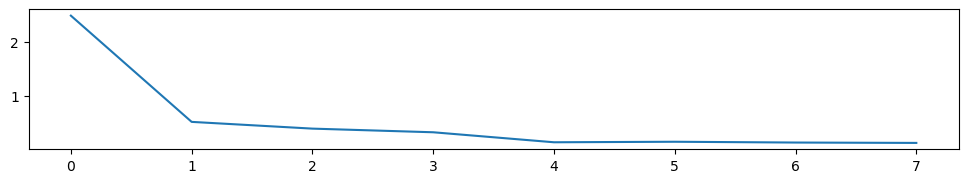

In [14]:
cost=[]
epoch=2
for iter in range(epoch):
     er=[]
     for i,(xbatch,ybatch) in enumerate(train_loader):
          model.train()
          # farward pass
          ypred= model(xbatch)
          optimizer.zero_grad()
          loss= criterion(ypred,ybatch.long())
          loss.backward()
          optimizer.step()

          er.append(loss.detach()) 
          if i%500==0:
               model.eval()
               loss= torch.mean(torch.tensor(er))
               cost.append(loss)
               # validation
               with torch.no_grad():
                    y_pred=[]
                    y_true=[]
                    for j,(xbatch,ybatch) in enumerate(val_loader):
                         # farward pass
                         ypred= model(xbatch)
                         ypred= torch.argmax(ypred,dim=1)
                         y_pred.extend(ypred.numpy())
                         y_true.extend(ybatch.numpy())
                         
                    y_pred= np.array(y_pred)
                    y_true= np.array(y_true)
                    accuracy= np.sum(y_true==y_pred)/y_pred.shape[0]*100
                    print(f'Loss({iter}:{i}): {loss:.6f} **** Valid Acc:{accuracy:.3f}%')
               model.train()
cost=torch.tensor(cost)
plt.figure(figsize=(12,4))
plt.subplot(2,1,1)
plt.plot(cost)
plt.show()

Total accuracy:98.880%
accuracy0:99.694%
accuracy1:99.295%
accuracy2:98.934%
accuracy3:98.614%
accuracy4:98.065%
accuracy5:98.206%
accuracy6:98.852%
accuracy7:99.125%
accuracy8:99.281%
accuracy9:98.612%


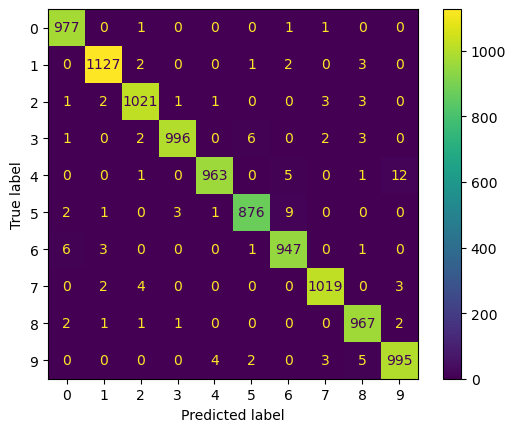

In [15]:
# validation
y_pred=[]
y_true=[]
model.eval()
with torch.no_grad():
    for i,(xbatch,ybatch) in enumerate(test_loader):
        # farward pass
        ypred= model(xbatch)
        ypred= torch.argmax(ypred,dim=1)
        y_pred.extend(ypred.numpy())
        y_true.extend(ybatch.numpy())
        
    y_pred= np.array(y_pred)
    y_true= np.array(y_true)

    from sklearn.metrics import confusion_matrix,ConfusionMatrixDisplay
    #%% test trained Neural Network
    C= confusion_matrix(y_true,y_pred)
    # print(C)
    accuracy= np.sum(np.diag(C))/ np.sum(C) *100
    print(f'Total accuracy:{accuracy:.3f}%')

for i in range(n_out):
    accuracyi= C[i,i]/ np.sum(C[i,:]) *100
    print(f'accuracy{i}:{accuracyi:.3f}%')
# plt.figure()
disp= ConfusionMatrixDisplay(C)
disp.plot()
plt.show()